In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt
from IPython.display import Video
from scipy.spatial.transform import Rotation

from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
import seaborn as sb
import itertools


import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#plt.style.use("seaborn-deep")

sb.set_palette("husl",3)
sb.set_style("whitegrid")

In [2]:
def load_and_label_data(file_paths, label):
    """Load data from multiple CSV files and assign a label."""
    data_list = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        # The CSV contains 'ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3'
        df['label'] = label
        data_list.append(df)
    return pd.concat(data_list)

### Load front_raise data

In [3]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/front_raise/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)


['../data/cleaned/front_raise\\front_raise1.csv', '../data/cleaned/front_raise\\front_raise10.csv', '../data/cleaned/front_raise\\front_raise11.csv', '../data/cleaned/front_raise\\front_raise12.csv', '../data/cleaned/front_raise\\front_raise13.csv', '../data/cleaned/front_raise\\front_raise14.csv', '../data/cleaned/front_raise\\front_raise15.csv', '../data/cleaned/front_raise\\front_raise16.csv', '../data/cleaned/front_raise\\front_raise17.csv', '../data/cleaned/front_raise\\front_raise18.csv', '../data/cleaned/front_raise\\front_raise19.csv', '../data/cleaned/front_raise\\front_raise2.csv', '../data/cleaned/front_raise\\front_raise20.csv', '../data/cleaned/front_raise\\front_raise21.csv', '../data/cleaned/front_raise\\front_raise22.csv', '../data/cleaned/front_raise\\front_raise23.csv', '../data/cleaned/front_raise\\front_raise24.csv', '../data/cleaned/front_raise\\front_raise25.csv', '../data/cleaned/front_raise\\front_raise26.csv', '../data/cleaned/front_raise\\front_raise27.csv', '

In [4]:
completedf_front_raise = load_and_label_data(excersise_files, 'front_raise')

In [5]:
completedf_front_raise

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,3218930,5635.0,6881.0,-1727.0,0.337,0.637,0.048,0.692,front_raise
1,3218946,5313.0,7701.0,-877.0,0.305,0.642,0.099,0.696,front_raise
2,3218962,4893.0,6717.0,29.0,0.283,0.642,0.134,0.700,front_raise
3,3218979,4827.0,4741.0,317.0,0.267,0.641,0.155,0.703,front_raise
4,3219005,4985.0,2377.0,565.0,0.253,0.641,0.169,0.705,front_raise
...,...,...,...,...,...,...,...,...,...
251,8426827,-809.0,-698.0,8056.0,0.982,-0.032,0.055,-0.175,front_raise
252,8426844,-793.0,-638.0,8178.0,0.982,-0.032,0.055,-0.175,front_raise
253,8426861,-777.0,-710.0,8104.0,0.982,-0.032,0.055,-0.175,front_raise
254,8426877,-823.0,-680.0,8106.0,0.982,-0.032,0.055,-0.175,front_raise


### Load shoulder_press data

In [6]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/shoulder_press/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/shoulder_press\\shoulder_press1.csv', '../data/cleaned/shoulder_press\\shoulder_press10.csv', '../data/cleaned/shoulder_press\\shoulder_press11.csv', '../data/cleaned/shoulder_press\\shoulder_press12.csv', '../data/cleaned/shoulder_press\\shoulder_press13.csv', '../data/cleaned/shoulder_press\\shoulder_press14.csv', '../data/cleaned/shoulder_press\\shoulder_press15.csv', '../data/cleaned/shoulder_press\\shoulder_press16.csv', '../data/cleaned/shoulder_press\\shoulder_press17.csv', '../data/cleaned/shoulder_press\\shoulder_press18.csv', '../data/cleaned/shoulder_press\\shoulder_press19.csv', '../data/cleaned/shoulder_press\\shoulder_press2.csv', '../data/cleaned/shoulder_press\\shoulder_press20.csv', '../data/cleaned/shoulder_press\\shoulder_press21.csv', '../data/cleaned/shoulder_press\\shoulder_press22.csv', '../data/cleaned/shoulder_press\\shoulder_press23.csv', '../data/cleaned/shoulder_press\\shoulder_press24.csv', '../data/cleaned/shoulder_press\\shoulder_press25

In [7]:
completedf_shoulder_press = load_and_label_data(excersise_files, 'shoulder_press')

In [8]:
completedf_shoulder_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,359849,-2411.0,-2335.0,-96.0,0.621,-0.501,0.483,0.360,shoulder_press
1,359865,-2529.0,-2209.0,302.0,0.620,-0.502,0.483,0.362,shoulder_press
2,359884,-3037.0,-2081.0,538.0,0.618,-0.505,0.481,0.362,shoulder_press
3,359900,-2829.0,-2329.0,426.0,0.617,-0.508,0.480,0.361,shoulder_press
4,359916,-2679.0,-1649.0,490.0,0.616,-0.513,0.478,0.358,shoulder_press
...,...,...,...,...,...,...,...,...,...
1096,2044427,-5300.0,2470.0,523.0,0.599,0.641,0.258,-0.403,shoulder_press
1097,2044445,-5060.0,6294.0,-165.0,0.600,0.649,0.242,-0.400,shoulder_press
1098,2044463,-7382.0,8172.0,-675.0,0.606,0.653,0.227,-0.393,shoulder_press
1099,2044481,-5510.0,7266.0,381.0,0.615,0.656,0.208,-0.385,shoulder_press


### Load barbell_bench_press data

In [9]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/barbell_bench_press/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/barbell_bench_press\\barbell_bench_press1.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press10.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press100.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press11.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press12.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press13.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press14.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press15.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press16.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press17.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press18.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press19.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press2.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press20.csv', '../data/cleaned/barbell_bench_press\\barbell_bench_press21.csv', '../data/c

In [10]:
completedf_barbell_bench_press = load_and_label_data(excersise_files, 'barbell_bench_press')

In [11]:
completedf_barbell_bench_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,276469,-7698.0,-3266.0,-1890.0,0.166,0.623,0.492,-0.584,barbell_bench_press
1,276486,-7882.0,-3020.0,-2204.0,0.168,0.623,0.492,-0.584,barbell_bench_press
2,276502,-7674.0,-3420.0,-1604.0,0.169,0.624,0.491,-0.584,barbell_bench_press
3,276519,-7446.0,-3158.0,-1630.0,0.170,0.624,0.489,-0.585,barbell_bench_press
4,276545,-7720.0,-2414.0,-1490.0,0.173,0.625,0.488,-0.585,barbell_bench_press
...,...,...,...,...,...,...,...,...,...
850,2520761,15637.0,-1470.0,-3459.0,0.200,0.557,0.279,-0.756,barbell_bench_press
851,2520778,16917.0,-3806.0,5837.0,0.226,0.508,0.240,-0.796,barbell_bench_press
852,2520795,16791.0,-2930.0,11657.0,0.247,0.472,0.176,-0.828,barbell_bench_press
853,2520811,17325.0,3196.0,15451.0,0.262,0.443,0.106,-0.851,barbell_bench_press


### Load curl

In [12]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/curl/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/curl\\curl1.csv', '../data/cleaned/curl\\curl10.csv', '../data/cleaned/curl\\curl11.csv', '../data/cleaned/curl\\curl12.csv', '../data/cleaned/curl\\curl13.csv', '../data/cleaned/curl\\curl14.csv', '../data/cleaned/curl\\curl15.csv', '../data/cleaned/curl\\curl16.csv', '../data/cleaned/curl\\curl17.csv', '../data/cleaned/curl\\curl18.csv', '../data/cleaned/curl\\curl19.csv', '../data/cleaned/curl\\curl2.csv', '../data/cleaned/curl\\curl20.csv', '../data/cleaned/curl\\curl21.csv', '../data/cleaned/curl\\curl22.csv', '../data/cleaned/curl\\curl23.csv', '../data/cleaned/curl\\curl24.csv', '../data/cleaned/curl\\curl25.csv', '../data/cleaned/curl\\curl26.csv', '../data/cleaned/curl\\curl27.csv', '../data/cleaned/curl\\curl28.csv', '../data/cleaned/curl\\curl29.csv', '../data/cleaned/curl\\curl3.csv', '../data/cleaned/curl\\curl30.csv', '../data/cleaned/curl\\curl31.csv', '../data/cleaned/curl\\curl32.csv', '../data/cleaned/curl\\curl33.csv', '../data/cleaned/curl\\curl34.

In [13]:
completedf_curl = load_and_label_data(excersise_files, 'curl')

In [14]:
completedf_curl

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,6054558,2903.0,6634.0,3302.0,0.768,0.539,0.004,0.345,curl
1,6054584,2879.0,6724.0,3336.0,0.769,0.539,0.003,0.344,curl
2,6054600,3015.0,6726.0,3360.0,0.769,0.538,0.002,0.344,curl
3,6054617,3099.0,6792.0,3346.0,0.770,0.538,0.001,0.344,curl
4,6054634,3071.0,6660.0,3504.0,0.770,0.537,0.000,0.343,curl
...,...,...,...,...,...,...,...,...,...
1387,1339665,7772.0,3358.0,-2071.0,0.419,0.702,-0.303,0.490,curl
1388,1339682,8054.0,3138.0,-2023.0,0.433,0.691,-0.310,0.489,curl
1389,1339699,8078.0,2098.0,-1681.0,0.446,0.680,-0.317,0.488,curl
1390,1339716,7790.0,1818.0,-1307.0,0.457,0.671,-0.323,0.486,curl


### Load dumbell_row data

In [15]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/dumbell_row/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/dumbell_row\\dumbell_row1.csv', '../data/cleaned/dumbell_row\\dumbell_row10.csv', '../data/cleaned/dumbell_row\\dumbell_row11.csv', '../data/cleaned/dumbell_row\\dumbell_row12.csv', '../data/cleaned/dumbell_row\\dumbell_row13.csv', '../data/cleaned/dumbell_row\\dumbell_row14.csv', '../data/cleaned/dumbell_row\\dumbell_row15.csv', '../data/cleaned/dumbell_row\\dumbell_row16.csv', '../data/cleaned/dumbell_row\\dumbell_row17.csv', '../data/cleaned/dumbell_row\\dumbell_row18.csv', '../data/cleaned/dumbell_row\\dumbell_row19.csv', '../data/cleaned/dumbell_row\\dumbell_row2.csv', '../data/cleaned/dumbell_row\\dumbell_row20.csv', '../data/cleaned/dumbell_row\\dumbell_row21.csv', '../data/cleaned/dumbell_row\\dumbell_row22.csv', '../data/cleaned/dumbell_row\\dumbell_row23.csv', '../data/cleaned/dumbell_row\\dumbell_row24.csv', '../data/cleaned/dumbell_row\\dumbell_row25.csv', '../data/cleaned/dumbell_row\\dumbell_row26.csv', '../data/cleaned/dumbell_row\\dumbell_row27.csv', '

In [16]:
completedf_dumbell_row = load_and_label_data(excersise_files, 'dumbell_row')

In [17]:
completedf_dumbell_row

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,3717016,8008.0,270.0,-1626.0,0.537,0.435,-0.640,0.335,dumbell_row
1,3717033,8064.0,330.0,-1634.0,0.536,0.435,-0.641,0.335,dumbell_row
2,3717050,8154.0,228.0,-1718.0,0.536,0.436,-0.641,0.335,dumbell_row
3,3717067,8194.0,162.0,-1774.0,0.535,0.436,-0.641,0.335,dumbell_row
4,3717084,8100.0,304.0,-1724.0,0.535,0.436,-0.641,0.335,dumbell_row
...,...,...,...,...,...,...,...,...,...
1329,4196470,6838.0,2420.0,-2494.0,0.551,0.506,-0.598,0.288,dumbell_row
1330,4196496,8698.0,3254.0,-3444.0,0.557,0.502,-0.600,0.279,dumbell_row
1331,4196512,7604.0,1640.0,-2678.0,0.564,0.496,-0.602,0.271,dumbell_row
1332,4196529,8832.0,2844.0,-3000.0,0.570,0.491,-0.605,0.263,dumbell_row


### Load french_press data

In [18]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/french_press/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/french_press\\french_press1.csv', '../data/cleaned/french_press\\french_press10.csv', '../data/cleaned/french_press\\french_press11.csv', '../data/cleaned/french_press\\french_press12.csv', '../data/cleaned/french_press\\french_press13.csv', '../data/cleaned/french_press\\french_press14.csv', '../data/cleaned/french_press\\french_press15.csv', '../data/cleaned/french_press\\french_press16.csv', '../data/cleaned/french_press\\french_press17.csv', '../data/cleaned/french_press\\french_press18.csv', '../data/cleaned/french_press\\french_press19.csv', '../data/cleaned/french_press\\french_press2.csv', '../data/cleaned/french_press\\french_press20.csv', '../data/cleaned/french_press\\french_press21.csv', '../data/cleaned/french_press\\french_press22.csv', '../data/cleaned/french_press\\french_press23.csv', '../data/cleaned/french_press\\french_press24.csv', '../data/cleaned/french_press\\french_press25.csv', '../data/cleaned/french_press\\french_press26.csv', '../data/clea

In [19]:
completedf_french_press = load_and_label_data(excersise_files, 'french_press')

In [20]:
completedf_french_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,5207551,-7704.0,1056.0,4817.0,0.855,0.095,0.510,-0.019,french_press
1,5207567,-8110.0,902.0,4711.0,0.849,0.082,0.522,-0.016,french_press
2,5207583,-9112.0,-252.0,4181.0,0.844,0.069,0.532,-0.011,french_press
3,5207609,-9114.0,214.0,3737.0,0.840,0.056,0.540,-0.006,french_press
4,5207625,-8582.0,812.0,2875.0,0.837,0.045,0.546,0.000,french_press
...,...,...,...,...,...,...,...,...,...
4036,5754261,-5806.0,-4489.0,-2856.0,0.556,-0.505,0.659,0.029,french_press
4037,5754277,-5828.0,-3881.0,-2354.0,0.558,-0.503,0.659,0.028,french_press
4038,5754303,-5872.0,-4421.0,-2742.0,0.559,-0.503,0.659,0.027,french_press
4039,5754320,-5710.0,-3929.0,-2284.0,0.561,-0.501,0.658,0.026,french_press


### Load rope_tricep_extension data

In [21]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/rope_tricep_pushdown/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown1.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown10.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown11.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown12.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown13.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown14.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown15.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown16.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown17.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown18.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown19.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown2.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown20.csv', '../data/cleaned/rope_tricep_pushdown\\rope_tricep_pushdown21.csv', '../data/cleaned/rope_tricep_pushdown\\rope_trice

In [22]:
completedf_rope_tricep_pushdown = load_and_label_data(excersise_files, 'rope_tricep_pushdown')

In [23]:
completedf_rope_tricep_pushdown

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,22194,-2050.0,1180.0,-412.0,0.651,0.511,0.481,0.289,rope_tricep_pushdown
1,22220,-2336.0,2158.0,-60.0,0.646,0.519,0.479,0.289,rope_tricep_pushdown
2,22236,-1896.0,2458.0,174.0,0.641,0.528,0.474,0.292,rope_tricep_pushdown
3,22252,-1526.0,2484.0,328.0,0.635,0.537,0.468,0.298,rope_tricep_pushdown
4,22268,-1344.0,3504.0,726.0,0.629,0.546,0.461,0.305,rope_tricep_pushdown
...,...,...,...,...,...,...,...,...,...
821,420754,-2604.0,7668.0,324.0,0.021,-0.147,0.682,0.716,rope_tricep_pushdown
822,420770,-2738.0,7084.0,258.0,0.028,-0.154,0.681,0.716,rope_tricep_pushdown
823,420787,-3034.0,6724.0,218.0,0.036,-0.161,0.679,0.715,rope_tricep_pushdown
824,420804,-3356.0,6834.0,182.0,0.043,-0.168,0.679,0.713,rope_tricep_pushdown


### Load side_raise data

In [24]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/side_raise/"
excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(excersise_files)

['../data/cleaned/side_raise\\side_raise.csv', '../data/cleaned/side_raise\\side_raise1.csv', '../data/cleaned/side_raise\\side_raise10.csv', '../data/cleaned/side_raise\\side_raise11.csv', '../data/cleaned/side_raise\\side_raise12.csv', '../data/cleaned/side_raise\\side_raise13.csv', '../data/cleaned/side_raise\\side_raise14.csv', '../data/cleaned/side_raise\\side_raise15.csv', '../data/cleaned/side_raise\\side_raise16.csv', '../data/cleaned/side_raise\\side_raise17.csv', '../data/cleaned/side_raise\\side_raise18.csv', '../data/cleaned/side_raise\\side_raise19.csv', '../data/cleaned/side_raise\\side_raise2.csv', '../data/cleaned/side_raise\\side_raise20.csv', '../data/cleaned/side_raise\\side_raise21.csv', '../data/cleaned/side_raise\\side_raise22.csv', '../data/cleaned/side_raise\\side_raise23.csv', '../data/cleaned/side_raise\\side_raise24.csv', '../data/cleaned/side_raise\\side_raise25.csv', '../data/cleaned/side_raise\\side_raise26.csv', '../data/cleaned/side_raise\\side_raise27.c

In [25]:
completedf_side_raise = load_and_label_data(excersise_files, 'side_raise')

In [26]:
completedf_side_raise

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,4175698,4201.0,-2552.0,4161.0,0.837,0.198,-0.174,0.479,side_raise
1,4175724,5033.0,-2700.0,4315.0,0.839,0.186,-0.205,0.468,side_raise
2,4175740,10853.0,-6938.0,8529.0,0.842,0.173,-0.223,0.460,side_raise
3,4175756,7279.0,-4268.0,9501.0,0.844,0.158,-0.233,0.456,side_raise
4,4175772,4305.0,-3212.0,10185.0,0.847,0.145,-0.240,0.452,side_raise
...,...,...,...,...,...,...,...,...,...
1956,857727,8294.0,5048.0,3822.0,0.552,0.660,-0.262,0.437,side_raise
1957,857743,8306.0,4904.0,3652.0,0.546,0.663,-0.267,0.438,side_raise
1958,857760,8260.0,5128.0,3746.0,0.540,0.665,-0.272,0.438,side_raise
1959,857776,8412.0,5146.0,3516.0,0.537,0.667,-0.277,0.437,side_raise


### Load non_exercise data

In [27]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/non_exersice/"
non_excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(non_excersise_files)

['../data/cleaned/non_exersice\\barbell_bench_press100_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press10_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press11_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press12_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press13_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press14_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press15_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press16_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press17_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press18_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press19_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press1_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press20_non_exersice.csv', '../data/cleaned/non_exersice\\barbell_bench_press21_non_exersi

In [28]:
completedf_non_exersice_press = load_and_label_data(non_excersise_files, 'non_exersice')

C:\Users\emder\AppData\Local\Temp\ipykernel_6108\350646870.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(data_list)


In [29]:
completedf_non_exersice_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,2523787,3999.0,9000.0,1199.0,0.194,-0.010,-0.606,-0.771,non_exersice
1,2523803,4393.0,9074.0,1287.0,0.200,-0.014,-0.610,-0.766,non_exersice
2,2523819,4489.0,8628.0,1563.0,0.204,-0.018,-0.614,-0.763,non_exersice
3,2523845,4603.0,8662.0,1733.0,0.206,-0.021,-0.616,-0.760,non_exersice
4,2523861,4409.0,8104.0,1953.0,0.207,-0.023,-0.619,-0.758,non_exersice
...,...,...,...,...,...,...,...,...,...
843,4175617,1161.0,-1132.0,3283.0,0.793,0.215,-0.040,0.569,non_exersice
844,4175633,1991.0,-1078.0,3789.0,0.807,0.216,-0.062,0.546,non_exersice
845,4175649,2987.0,-724.0,3839.0,0.818,0.218,-0.086,0.525,non_exersice
846,4175665,3931.0,-902.0,3891.0,0.827,0.215,-0.113,0.507,non_exersice


### Concatenate into one dataframe

In [30]:
df_concatenated = pd.concat([completedf_front_raise, completedf_shoulder_press, completedf_barbell_bench_press, completedf_curl, completedf_dumbell_row, completedf_french_press, completedf_rope_tricep_pushdown, completedf_side_raise, completedf_non_exersice_press], ignore_index=True)

In [31]:
df_concatenated

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,3218930,5635.0,6881.0,-1727.0,0.337,0.637,0.048,0.692,front_raise
1,3218946,5313.0,7701.0,-877.0,0.305,0.642,0.099,0.696,front_raise
2,3218962,4893.0,6717.0,29.0,0.283,0.642,0.134,0.700,front_raise
3,3218979,4827.0,4741.0,317.0,0.267,0.641,0.155,0.703,front_raise
4,3219005,4985.0,2377.0,565.0,0.253,0.641,0.169,0.705,front_raise
...,...,...,...,...,...,...,...,...,...
1187259,4175617,1161.0,-1132.0,3283.0,0.793,0.215,-0.040,0.569,non_exersice
1187260,4175633,1991.0,-1078.0,3789.0,0.807,0.216,-0.062,0.546,non_exersice
1187261,4175649,2987.0,-724.0,3839.0,0.818,0.218,-0.086,0.525,non_exersice
1187262,4175665,3931.0,-902.0,3891.0,0.827,0.215,-0.113,0.507,non_exersice


### Split into X, Y

In [32]:
def split_sequences(dataframe, sequence_length):
    """Split the dataframe into sequences of a given length, including all relevant columns."""
    X, y = [], []
    columns_of_interest = ['q0', 'q1', 'q2', 'q3']
    for i in range(0, len(dataframe) - sequence_length + 1, sequence_length):
        sequence = dataframe.iloc[i:i+sequence_length][columns_of_interest]
        label = dataframe.iloc[i]['label']
        X.append(sequence.values)
        y.append(label)
    return np.array(X), np.array(y)

In [33]:
x, y = split_sequences(df_concatenated, 500)

In [34]:
len(x), len(y)

(2374, 2374)

## Model Train

### Split into train, test, val set

In [35]:
X_train_val, X_val, y_train_val, y_val = train_test_split(x, y, test_size=0.1)
X_train, X_test, y_train, y_test = train_test_split(X_train_val, y_train_val, test_size=0.1)

In [36]:
len(np.unique(y_train))

9

In [37]:
y_train.shape, X_train.shape

((1922,), (1922, 500, 4))

In [38]:
y_test.shape, X_test.shape

((214,), (214, 500, 4))

In [39]:
y_val.shape, X_val.shape

((238,), (238, 500, 4))

### Convert to one hot encoding

In [40]:
class_names = np.unique(y_train)
num_classes = len(np.unique(y_train))
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert text labels into numeric identifiers
y_train_encoded = label_encoder.fit_transform(y_train)

# Convert numeric labels into one-hot
y_train_one_hot = to_categorical(y_train_encoded)


# Convert text labels into numeric identifiers
y_val_encoded = label_encoder.fit_transform(y_val)


# Convert numeric labels into one-hot
y_val_one_hot = to_categorical(y_val_encoded)

# Convert text labels into numeric identifiers
y_test_encoded = label_encoder.fit_transform(y_test)

# Convert numeric labels into one-hot
y_test_one_hot = to_categorical(y_test_encoded)

### Define model

In [41]:
# Define the model
inputs = tf.keras.Input(shape=(500, 4))

# Apply Dense layers to the inputs
layer = keras.layers.Dense(128, activation=tf.nn.relu6)(inputs)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(64, activation=tf.nn.relu6)(layer)
layer = keras.layers.Dropout(0.5)(layer)

# Add GlobalAveragePooling1D to reduce dimensionality
layer = keras.layers.GlobalAveragePooling1D()(layer)

# Final layer for classification
outputs = keras.layers.Dense(len(np.unique(y_train)), activation="softmax")(layer)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 500, 4)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 500, 128)            │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 500, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 500, 64)             │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 500, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │             585 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,481 (37.04 KB)

 Trainable params: 9,481 (37.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [46]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
checkpoint_path = "weights.best.hdf5"
checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', 
                                              patience=50)

# Start training
print(X_train.shape)
history = model.fit(X_train, y_train_one_hot,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_val, y_val_one_hot),
                    callbacks=[checkpoint, earlystopping],
                    )

Filepath provided did not end in '.keras'. Continuing anyways...
(1922, 500, 4)
Epoch 1/50
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8805 - loss: 0.3333
Epoch 1: val_accuracy improved from -inf to 0.86555, saving model to weights.best.hdf5


121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8807 - loss: 0.3332 - val_accuracy: 0.8655 - val_loss: 0.5253
Epoch 2/50
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8967 - loss: 0.3001
Epoch 2: val_accuracy did not improve from 0.86555
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8963 - loss: 0.3009 - val_accuracy: 0.8529 - val_loss: 0.5354
Epoch 3/50
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8786 - loss: 0.3390
Epoch 3: val_accuracy did not improve from 0.86555
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8787 - loss: 0.3388 - val_accuracy: 0.8571 - val_loss: 0.5294
Epoch 4/50
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8840 - loss: 0.3418
Epoch 4: val_accuracy did not improve from 0.86555
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8838 - loss: 0.3418 - val_accuracy: 0.8613 - val_loss: 0.5100
Epoch 5/50
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8856 - loss: 0.3261
Epoch 5: val_accuracy impro

121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8856 - loss: 0.3263 - val_accuracy: 0.8739 - val_loss: 0.5189
Epoch 6/50
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8680 - loss: 0.3664
Epoch 6: val_accuracy did not improve from 0.87395
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8683 - loss: 0.3659 - val_accuracy: 0.8613 - val_loss: 0.5311
Epoch 7/50
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8782 - loss: 0.3354
Epoch 7: val_accuracy did not improve from 0.87395
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8783 - loss: 0.3353 - val_accuracy: 0.8613 - val_loss: 0.5299
Epoch 8/50
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8708 - loss: 0.3417
Epoch 8: val_accuracy did not improve from 0.87395
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8711 - loss: 0.3415 - val_accuracy: 0.8487 - val_loss: 0.5348
Epoch 9/50
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8901 - loss: 0.2949
Epoch 9: val_accuracy did n

### Plot graph

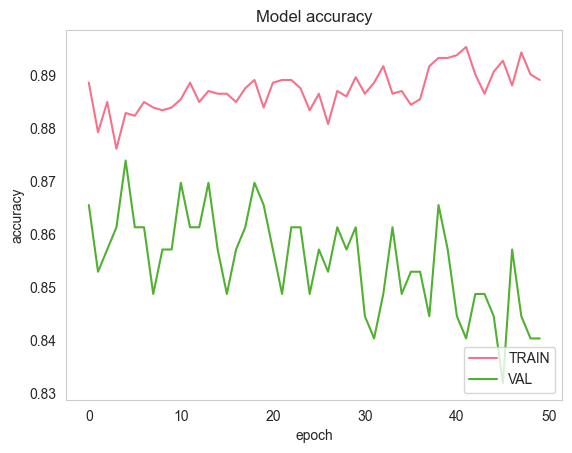

In [47]:
# Visualize the training history to see whether you're overfitting.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')
plt.grid()
plt.show()

### Plot confusion matrix

In [48]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8403 - loss: 0.4365


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Confusion matrix, without normalization

Classification Report:
                       precision    recall  f1-score   support

 barbell_bench_press       0.80      0.92      0.86        13
                curl       0.96      0.83      0.89        29
         dumbell_row       0.77      0.91      0.83        11
        french_press       0.69      0.79      0.73        14
         front_raise       1.00      0.82      0.90        11
        non_exersice       0.81      0.84      0.82        85
rope_tricep_pushdown       0.88      0.93      0.90        15
      shoulder_press       0.96      0.96      0.96        26
          side_raise       1.00      0.60      0.75        10

            accuracy                           0.85       214
           macro avg       0.87      0.84      0.85       214
        weighted avg       0.86      0.85      0.85       214



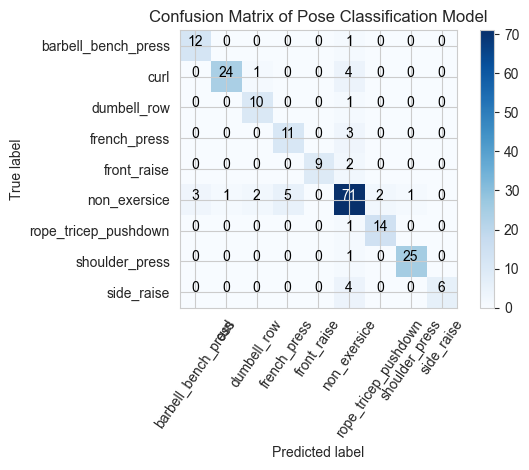

In [49]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

# Classify pose in the TEST dataset using the trained model
y_pred = model.predict(X_test)

# Convert the prediction result to class name
y_pred_label = [class_names[i] for i in np.argmax(y_pred, axis=1)]
y_true_label = [class_names[i] for i in np.argmax(y_test_one_hot, axis=1)]

# Plot the confusion matrix
cm = confusion_matrix(np.argmax(y_test_one_hot, axis=1), np.argmax(y_pred, axis=1))
plot_confusion_matrix(cm,
                      class_names,
                      title ='Confusion Matrix of Pose Classification Model')

# Print the classification report
print('\nClassification Report:\n', classification_report(y_true_label, y_pred_label))